In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Vars:

In [3]:
TARGET = 'class'
N_FOLDS = 5
RANDOM_STATE = 42

In [4]:
le = LabelEncoder()
ohe = OneHotEncoder()

In [5]:
train_df = pd.read_csv('data/train.csv')
target_col = train_df[TARGET]
train_df=  train_df.drop(columns=['id', TARGET]) # Remove the id and class cols

test_df = pd.read_csv('data/test.csv')

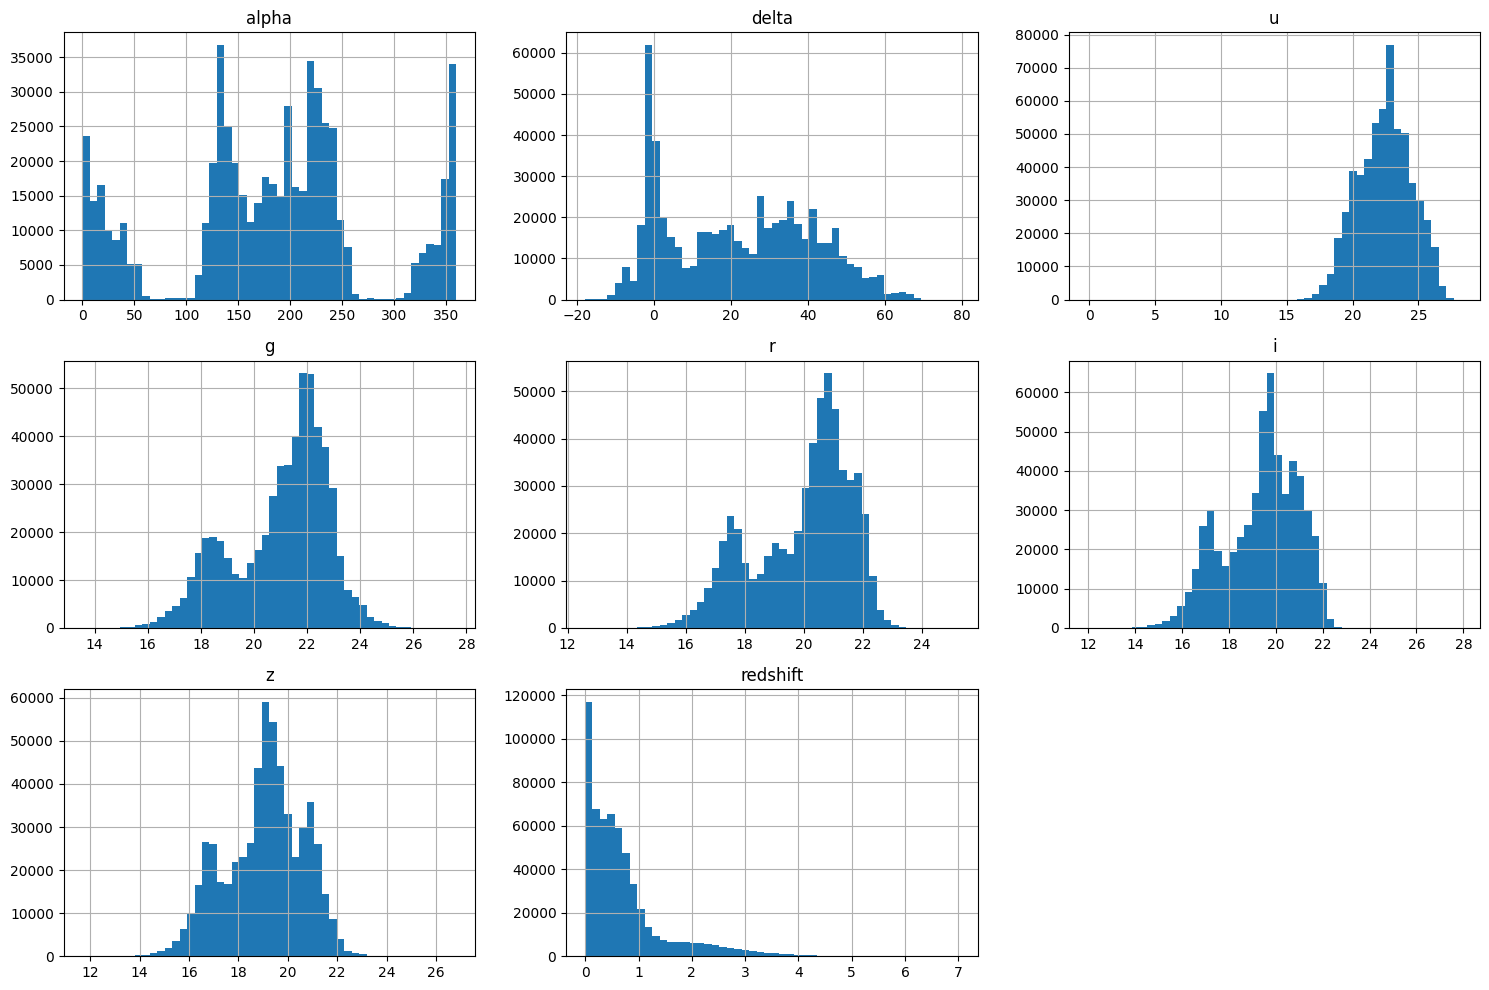

In [6]:
train_df.hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.show()


In [7]:
train_df.select_dtypes(include='number').corr()

,alpha,delta,u,g,r,i,z,redshift
alpha,1.000000,0.143541,-0.017242,-0.037731,-0.037830,-0.029333,-0.024583,0.007989
delta,0.143541,1.000000,-0.026860,-0.008386,-0.004395,0.002088,0.003347,0.053763
u,-0.017242,-0.026860,1.000000,0.826880,0.659410,0.521811,0.443923,0.078903
g,-0.037731,-0.008386,0.826880,1.000000,0.912066,0.805020,0.731737,0.237447
r,-0.037830,-0.004395,0.659410,0.912066,1.000000,0.953550,0.913341,0.390989
i,-0.029333,0.002088,0.521811,0.805020,0.953550,1.000000,0.968715,0.466575
z,-0.024583,0.003347,0.443923,0.731737,0.913341,0.968715,1.000000,0.480860
redshift,0.007989,0.053763,0.078903,0.237447,0.390989,0.466575,0.480860,1.000000


In [8]:
target_col.value_counts(normalize=True)

class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: proportion, dtype: float64

### Feature engineering

In [ ]:
for df in [train_df, test_df]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_z'] = df['u'] - df['z']
    df['log_redshift'] = np.log1p(df['redshift'].clip(lower=0))
    df['abs_delta'] = df['delta'].abs()

In [10]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

In [11]:
train_df = pd.get_dummies(train_df, columns=['spectral_type', 'galaxy_population'])
test_df = pd.get_dummies(test_df, columns=['spectral_type', 'galaxy_population'])

In [12]:
train_df.head(10)

,alpha,delta,u,g,r,i,z,redshift,u_g,g_r,r_i,i_z,log_redshift,abs_delta,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,3.576564,1.537632,1.100813,0.636056,0.342868,16.959273,False,False,True,False,False,True
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,1.691447,1.499854,0.361141,0.439634,0.146673,32.346716,False,False,True,False,False,True
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,-0.043925,-0.092712,0.589211,0.025263,1.341237,35.344843,False,False,False,True,True,False
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,2.254320,2.032982,0.652096,0.450706,0.429246,48.569421,False,False,True,False,False,True
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,2.231478,1.237231,0.335002,0.283262,0.441965,19.342852,False,False,True,False,False,True
5,250.727869,31.756548,20.926469,19.693480,18.902361,19.247572,18.508241,0.076299,1.232989,0.791119,-0.345211,0.739331,0.073528,31.756548,False,True,False,False,True,False
6,0.752529,-2.936677,22.829195,22.686143,20.583886,19.781338,19.410491,0.575080,0.143052,2.102257,0.802549,0.370847,0.454306,2.936677,False,False,True,False,False,True
7,235.611325,39.626517,22.511467,21.480306,21.765645,21.508658,21.333476,2.159269,1.031161,-0.285339,0.256987,0.175182,1.150341,39.626517,False,False,False,True,True,False
8,355.359230,2.182312,20.396550,20.064767,19.892257,19.836272,19.860081,0.900087,0.331783,0.172510,0.055985,-0.023809,0.641900,2.182312,True,False,False,False,True,False
9,254.980080,38.743449,18.839137,17.997845,18.458894,18.229552,19.202247,0.114302,0.841292,-0.461050,0.229342,-0.972695,0.108228,38.743449,False,False,False,True,True,False


In [13]:
X = train_df
y = target_col

y = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)

In [14]:
xgbc_model = XGBClassifier(
    subsample=0.9,
    reg_lambda=0.5,
    reg_alpha=0.1,
    n_estimators=700,
    min_child_weight=5,
    max_depth=6,
    learning_rate=0.1,
    gamma=0,
    colsample_bytree=0.7,
    random_state=RANDOM_STATE,
    objective='multi:softprob',
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    n_jobs=-1,
    tree_method='hist'
)
xgbc_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

[0]	validation_0-mlogloss:0.77501
[100]	validation_0-mlogloss:0.10408
[200]	validation_0-mlogloss:0.09625
[300]	validation_0-mlogloss:0.09311
[400]	validation_0-mlogloss:0.09184
[500]	validation_0-mlogloss:0.09128
[600]	validation_0-mlogloss:0.09090
[699]	validation_0-mlogloss:0.09081


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [15]:
y_pred_xgb = xgbc_model.predict(X_val)

In [16]:
pd.Series(xgbc_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

spectral_type_M                   0.394998
galaxy_population_Blue_Cloud      0.310050
log_redshift                      0.064278
redshift                          0.049991
galaxy_population_Red_Sequence    0.035533
spectral_type_O/B                 0.028440
g_r                               0.026033
z                                 0.018221
g                                 0.011851
r_i                               0.010676
u                                 0.010259
u_g                               0.009387
i                                 0.005993
spectral_type_G/K                 0.005960
r                                 0.004319
alpha                             0.003874
i_z                               0.002627
abs_delta                         0.002620
delta                             0.002460
spectral_type_A/F                 0.002432
dtype: float32

In [17]:
catboost_model = CatBoostClassifier(
    iterations=700,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    eval_metric='TotalF1:average=Macro',
    l2_leaf_reg=3,
    random_seed=RANDOM_STATE,
    verbose=100,
    thread_count=-1
)
catboost_model.fit(X_train, y_train, eval_set=(X_val, y_val))

0:	learn: 0.8750350	test: 0.8748784	best: 0.8748784 (0)	total: 1.44s	remaining: 16m 48s
100:	learn: 0.9422041	test: 0.9419113	best: 0.9419113 (100)	total: 31.3s	remaining: 3m 5s
200:	learn: 0.9489901	test: 0.9478244	best: 0.9479906 (196)	total: 1m	remaining: 2m 31s
300:	learn: 0.9516590	test: 0.9496707	best: 0.9496854 (298)	total: 1m 34s	remaining: 2m 5s
400:	learn: 0.9532854	test: 0.9511605	best: 0.9511605 (400)	total: 2m 1s	remaining: 1m 30s
500:	learn: 0.9544963	test: 0.9520240	best: 0.9520240 (500)	total: 2m 29s	remaining: 59.3s
600:	learn: 0.9556450	test: 0.9525543	best: 0.9525577 (584)	total: 3m 24s	remaining: 33.7s
699:	learn: 0.9564306	test: 0.9530473	best: 0.9530489 (698)	total: 4m 16s	remaining: 0us

bestTest = 0.9530488705
bestIteration = 698

Shrink model to first 699 iterations.


CatBoostClassifier(depth=6, eval_metric='TotalF1:average=Macro', iterations=700, l2_leaf_reg=3, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

## Results:

In [18]:
# Catboost:
y_pred_cat = catboost_model.predict(X_val).flatten()
print(f"CatBoost model: {balanced_accuracy_score(y_val, y_pred_cat)}")

# XGBoost:
print(f"XGBoost model: {balanced_accuracy_score(y_val, y_pred_xgb)}")

# Ensemble (soft voting):
proba_xgb = xgbc_model.predict_proba(X_val)
proba_cat = catboost_model.predict_proba(X_val)
ensemble_preds = np.argmax(proba_xgb + proba_cat, axis=1)
print(f"Ensemble model: {balanced_accuracy_score(y_val, ensemble_preds)}")

CatBoost model: 0.951741179312295
XGBoost model: 0.9545399685254948
Ensemble model: 0.9548749235853453


In [19]:
test_ids = test_df['id']
X_test = test_df.drop(columns=['id'])

# XGBoost submission
xgb_preds = le.inverse_transform(xgbc_model.predict(X_test))
pd.DataFrame({'id': test_ids, 'class': xgb_preds}).to_csv('submission_xgb.csv', index=False)

# CatBoost submission
cat_preds = le.inverse_transform(catboost_model.predict(X_test).flatten().astype(int))
pd.DataFrame({'id': test_ids, 'class': cat_preds}).to_csv('submission_catboost.csv', index=False)

# Ensemble submission
proba_xgb_test = xgbc_model.predict_proba(X_test)
proba_cat_test = catboost_model.predict_proba(X_test)
ensemble_preds_test = le.inverse_transform(np.argmax(proba_xgb_test + proba_cat_test, axis=1))
pd.DataFrame({'id': test_ids, 'class': ensemble_preds_test}).to_csv('submission_ensemble.csv', index=False)

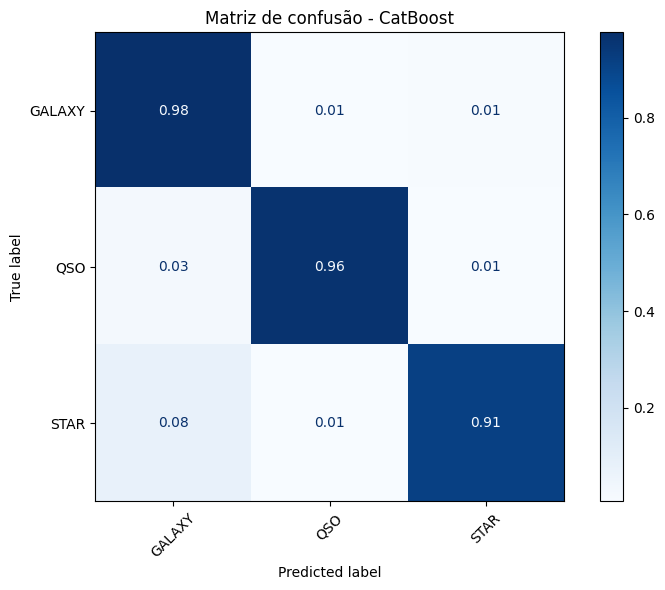

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_cat.astype(int),
    display_labels=le.classes_,
    normalize='true',
    cmap='Blues',
    values_format='.2f',
    ax=ax
)

ax.set_title('Matriz de confusão - CatBoost')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()